# Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners?

Answer:

Boosting is an ensemble learning technique that combines multiple weak learners to create a strong model. A weak learner is a model that performs only slightly better than random guessing.

Boosting works sequentially. Each new model focuses more on the samples that were misclassified by previous models. By repeatedly correcting errors, boosting gradually improves performance.

Key idea:

Train models one after another

Give higher importance to misclassified points

Combine all models into a final strong predictor

This process reduces bias and improves accuracy.

----

# Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?

Answer: AdaBoost:

Adjusts weights of misclassified samples.

New learners focus more on incorrectly predicted points.

Combines models using weighted voting.

Gradient Boosting:

Fits new models on the residual errors (gradients).

Uses optimization techniques to minimize loss.

More flexible and supports different loss functions.

---

# Question 3: How does regularization help in XGBoost?

Answer:

Regularization in XGBoost penalizes model complexity using L1 and L2 penalties.

Benefits:

Prevents overfitting

Controls tree depth and leaf weights

Improves generalization

Produces simpler, more robust models

XGBoost explicitly includes regularization in its objective function, which makes it more stable than traditional Gradient Boosting.

---
## Question 4: Why is CatBoost considered efficient for handling categorical data?

Answer:

CatBoost directly handles categorical features without manual encoding.

Advantages:

Automatically converts categorical variables internally

Uses ordered target statistics to prevent data leakage

Handles missing values naturally

Reduces preprocessing effort

Provides strong performance out of the box

This makes CatBoost especially useful for real-world datasets with many categorical columns.


---
# Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?

Answer:

Boosting is preferred when high accuracy is required, such as:

Credit risk prediction

Fraud detection

Medical diagnosis

Customer churn prediction

Search ranking systems

Recommendation engines

Boosting reduces bias and captures complex patterns, whereas bagging mainly reduces variance.









# Question 6:Write a Python program to:
● Train an AdaBoost Classifier on the Breast Cancer dataset
● Print the model accuracy

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = AdaBoostClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("AdaBoost Accuracy:", accuracy)


AdaBoost Accuracy: 0.9736842105263158


Question 7: Gradient Boosting Regressor on California Housing Dataset

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

X, y = fetch_california_housing(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)


R2 Score: 0.7756446042829697


# Question 8:XGBoost Classifier with GridSearchCV

In [3]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

params = {
    "learning_rate": [0.01, 0.1, 0.2]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")

grid = GridSearchCV(xgb, params, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:08:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:08:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:08:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:08:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:08:55] WARNING: /w

Best Parameters: {'learning_rate': 0.1}
Accuracy: 0.956140350877193


Question 9: CatBoost Classifier & Confusion Matrix

In [8]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00


Accuracy: 0.9736842105263158


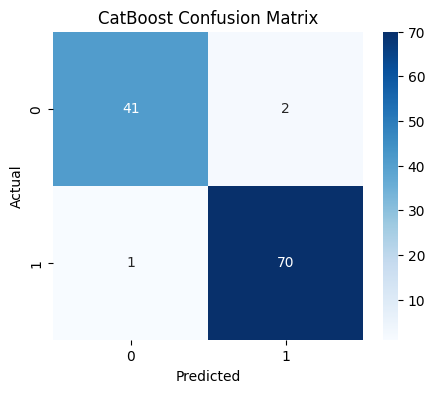

In [9]:
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
X, y = load_breast_cancer(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train CatBoost
model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CatBoost Confusion Matrix")
plt.show()


## Question 10: FinTech Loan Default Prediction Pipeline

Answer:

1. Data Preprocessing

Handle missing values using median/mode.

Encode categorical variables (CatBoost handles this automatically).

Scale numeric features if needed.

Address imbalance using SMOTE or class weights.

2. Model Choice

Prefer CatBoost or XGBoost due to mixed data types and missing values.

CatBoost is ideal for categorical-heavy data.

3. Hyperparameter Tuning

Use GridSearchCV or RandomizedSearchCV.

Tune learning rate, depth, estimators.

4. Evaluation Metrics

ROC-AUC (imbalanced data)

Precision, Recall, F1-score

Confusion Matrix

Accuracy alone is insufficient for financial risk.

5. Business Benefits

Better default prediction

Reduced financial losses

Improved credit decisions

Automated risk scoring

Higher customer trust